# Notebook 02 — LLM Law-of-Large-Numbers experiment

**Question this notebook answers:** When several local LLMs each rank a cohort
of borrowers via pairwise comparisons (no numeric scales — Bradley-Terry only),
does the **group consensus** PD converge toward the empirical default rate as
the number of models averaged grows? Which model families pull the consensus
in which direction?

**Why pairwise, not numeric:** A numeric "give me a 1–10 risk score" prompt is
sensitive to LLM weight updates and prompt drift — the same model after a
quantisation change can shift its score distribution by several points. A
pairwise "which is riskier, A or B?" comparison only requires the *ordering*
to be stable. We fit Bradley-Terry on the wins to recover a latent strength
per profile, then map strengths to log-odds via a fixed calibration.

In [1]:
from __future__ import annotations
import sys, sqlite3
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(PROJECT_ROOT), str(PROJECT_ROOT / "notebooks")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import joblib, json

from src.config import load_config
from src.data_pipeline import load_and_combine, out_of_time_split
from src.ollama_client import list_available_models, OllamaConnectionError, infer_model_family
from src.bradley_terry import (
    construct_pairwise_prompts, run_pairwise_experiment, fit_bradley_terry,
    validate_bt_stability, SYSTEM_PROMPT,
)
from src.bootstrap import bootstrap_convergence_ci

cfg = load_config(str(PROJECT_ROOT / "config.yaml"))
PALETTE = cfg["colours"]
DB_PATH = str(PROJECT_ROOT / cfg["data"]["db_path"])

sns.set_style("whitegrid", {"axes.grid": True, "grid.alpha": 0.3, "grid.color": "#cbd5e1"})
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
    "axes.facecolor": PALETTE["background"], "figure.facecolor": "white",
})

# --- demo-scale knob: 6 profiles → 15 pairs/model; full 10-profile run = 45 pairs/model
N_PROFILES_DEMO = 6
N_HIGH_IV_FEATURES = 5

## 1 — Cohort selection

We pull a balanced cohort from the OOT test set (50/50 defaulted vs not),
restricted to the top-IV features. The LLM has to discriminate using only
those features; we want the cohort small enough that pairwise queries fit in
~10 minutes of execution time.

In [2]:
df = load_and_combine(str(PROJECT_ROOT / cfg["data"]["raw_dir"]), cfg["data"]["target_col"])
X_tr, y_tr, X_te, y_te = out_of_time_split(
    df, cfg["data"]["date_col"], cfg["data"]["train_years"], cfg["data"]["test_years"], cfg["data"]["target_col"]
)

# Reuse the latest LR artefact to get IV ranking → choose the top features for the prompt.
artefact_dir = PROJECT_ROOT / cfg["data"]["artefacts_dir"]
lr_artefacts = sorted(artefact_dir.glob("lr_pipeline_*.joblib"))
assert lr_artefacts, "no LR artefact found — run notebook 01 first"
lr_bundle = joblib.load(lr_artefacts[-1])
encoder = lr_bundle["encoder"] if isinstance(lr_bundle, dict) else lr_bundle.named_steps["woe"]
iv = pd.Series(encoder.iv_).sort_values(ascending=False)
top_features = iv.head(N_HIGH_IV_FEATURES).index.tolist()
print(f"Top {N_HIGH_IV_FEATURES} features by IV (used in prompts): {top_features}")

# Stratified cohort: half defaulted, half not.
rng = np.random.default_rng(cfg["bootstrap"]["seed"])
half = N_PROFILES_DEMO // 2
pos_idx = X_te.index[y_te == 1]
neg_idx = X_te.index[y_te == 0]
sel = list(rng.choice(pos_idx, size=half, replace=False)) + list(rng.choice(neg_idx, size=N_PROFILES_DEMO - half, replace=False))
cohort_full = X_te.loc[sel].copy()           # all 64 features, for LR scoring
cohort_X = cohort_full[top_features].copy()  # restricted view, for LLM prompts
cohort_y = y_te.loc[sel].copy()
profile_ids_list = [f"p{i:02d}" for i in range(len(cohort_X))]
cohort_X["profile_id"] = profile_ids_list
cohort_full["profile_id"] = profile_ids_list
profiles = [
    {"id": row["profile_id"], **{f: row[f] for f in top_features}}
    for _, row in cohort_X.iterrows()
]
profile_truth = pd.Series(cohort_y.to_numpy(), index=cohort_X["profile_id"], name="defaulted")
print(f"Cohort: n={len(profiles)}, defaulted={int(profile_truth.sum())}/{len(profiles)}")

Top 5 features by IV (used in prompts): ['Attr27', 'Attr24', 'Attr26', 'Attr16', 'Attr41']
Cohort: n=6, defaulted=3/6


## 2 — Discover available Ollama models

In [3]:
try:
    available = list_available_models(cfg["llm"]["ollama_base_url"])
except OllamaConnectionError as exc:
    print(f"Ollama server not reachable: {exc}")
    available = []
preferred_order = ["qwen2.5:0.5b", "tinyllama:latest", "llama3.2:latest", "phi3:mini"]
models = [m for m in preferred_order if m in available] or available
print(f"Using models ({len(models)}): {models}")

Using models (4): ['qwen2.5:0.5b', 'tinyllama:latest', 'llama3.2:latest', 'phi3:mini']


## 3 — Run pairwise experiment (cached)

The notebook checks SQLite for any pre-existing comparisons. Only the
(model, profile_a, profile_b) triples that are missing are sent to Ollama.

In [4]:
def cached_comparisons(models, profile_ids, db_path):
    if not Path(db_path).exists():
        return pd.DataFrame()
    with sqlite3.connect(db_path) as conn:
        q = f"SELECT model_name, model_family, profile_a_id, profile_b_id, winner_id, raw_response, query_timestamp FROM borrower_comparisons WHERE model_name IN ({','.join(['?']*len(models))}) AND profile_a_id IN ({','.join(['?']*len(profile_ids))})"
        df = pd.read_sql_query(q, conn, params=list(models) + list(profile_ids))
    return df

profile_ids = [p["id"] for p in profiles]
cached = cached_comparisons(models, profile_ids, DB_PATH)
n_pairs_per_model = (len(profiles) * (len(profiles) - 1)) // 2
need_queries = []
for m in models:
    have = cached[cached["model_name"] == m]
    pairs_have = set(zip(have["profile_a_id"], have["profile_b_id"]))
    expected_pairs = [(a["id"], b["id"]) for i, a in enumerate(profiles) for b in profiles[i+1:]]
    pairs_missing = [p for p in expected_pairs if p not in pairs_have]
    print(f"  {m:25s}: cached {len(pairs_have)}/{n_pairs_per_model}, need {len(pairs_missing)}")
    if pairs_missing:
        need_queries.append(m)

if need_queries:
    from datetime import datetime, timezone
    print(f"\nQuerying {len(need_queries)} model(s) live (this may take ~10 minutes)…")
    fresh = run_pairwise_experiment(
        models=need_queries, profiles=profiles,
        task="borrower_level", category="",
        cfg=cfg, db_path=DB_PATH,
        progress=lambda m, d, t: print(f"  [{m}] {d}/{t}", end="\r"),
    )
    print()
    cached = pd.concat([cached, fresh[cached.columns]], ignore_index=True)

# de-duplicate on the natural key, keeping the latest run
cached = (cached.sort_values("query_timestamp")
                .drop_duplicates(subset=["model_name", "profile_a_id", "profile_b_id"], keep="last")
                .reset_index(drop=True))
print(f"\nTotal comparisons available: {len(cached)} across {cached['model_name'].nunique()} models")
cached.head()

  qwen2.5:0.5b             : cached 15/15, need 0
  tinyllama:latest         : cached 15/15, need 0
  llama3.2:latest          : cached 15/15, need 0
  phi3:mini                : cached 15/15, need 0

Total comparisons available: 60 across 4 models


,model_name,model_family,profile_a_id,profile_b_id,winner_id,raw_response,query_timestamp
0,qwen2.5:0.5b,qwen,p00,p01,A,A,2026-05-29T23:08:34.745304+00:00
1,qwen2.5:0.5b,qwen,p00,p02,A,A,2026-05-29T23:08:34.911243+00:00
2,qwen2.5:0.5b,qwen,p00,p03,A,A,2026-05-29T23:08:35.062990+00:00
3,qwen2.5:0.5b,qwen,p00,p04,A,A,2026-05-29T23:08:35.214719+00:00
4,qwen2.5:0.5b,qwen,p00,p05,A,A,2026-05-29T23:08:35.366734+00:00


## 4 — Fit Bradley-Terry per model

In [5]:
bt_by_model = {}
gini_by_model = {}
for m in cached["model_name"].unique():
    sub = cached[cached["model_name"] == m]
    if not sub["winner_id"].isin(["A", "B"]).any():
        print(f"  {m}: no valid A/B winners — skipping")
        continue
    bt = fit_bradley_terry(sub)
    bt_by_model[m] = bt.reindex(profile_ids).fillna(0.0)
    try:
        gini_by_model[m] = float(2 * roc_auc_score(profile_truth.reindex(bt_by_model[m].index), bt_by_model[m]) - 1)
    except ValueError:
        gini_by_model[m] = float("nan")
    print(f"  {m:25s}  Gini vs ground truth = {gini_by_model[m]:+.3f}")

bt_matrix = pd.DataFrame(bt_by_model)
gini_series = pd.Series(gini_by_model).sort_values(ascending=False)
print()
print("Per-model BT-vs-truth Gini (sorted):")
print(gini_series.round(3).to_string())

  qwen2.5:0.5b               Gini vs ground truth = +1.000
  tinyllama:latest           Gini vs ground truth = +1.000
  llama3.2:latest            Gini vs ground truth = -0.333
  phi3:mini                  Gini vs ground truth = -0.111

Per-model BT-vs-truth Gini (sorted):
qwen2.5:0.5b        1.000
tinyllama:latest    1.000
phi3:mini          -0.111
llama3.2:latest    -0.333


### Chart 1 — Pairwise model agreement matrix

Each cell is the fraction of borrower pairs on which model *i* and model *j*
picked the same winner. Diagonal = 1.0 by construction. Off-diagonal cells
near 1 indicate models that consistently rank borrowers the same way;
cells near 0.5 indicate disagreement at chance level.

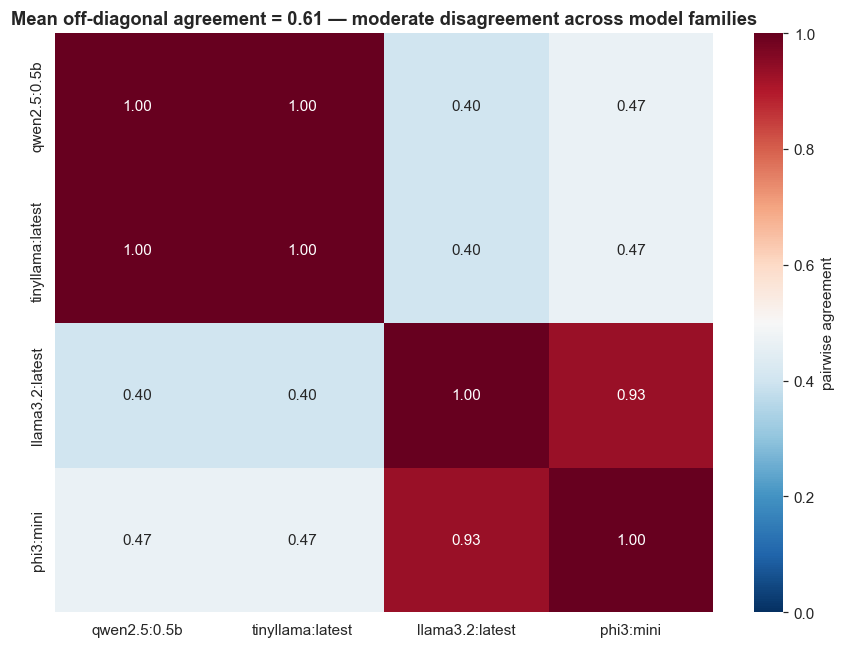

In [6]:
models_with_bt = list(bt_by_model.keys())
pairs_lookup = {}
for _, row in cached.iterrows():
    if row["winner_id"] not in ("A", "B"):
        continue
    key = (row["profile_a_id"], row["profile_b_id"])
    pairs_lookup.setdefault(key, {})[row["model_name"]] = row["winner_id"]

agreement = pd.DataFrame(index=models_with_bt, columns=models_with_bt, dtype=float)
for m1 in models_with_bt:
    for m2 in models_with_bt:
        agree, total = 0, 0
        for key, picks in pairs_lookup.items():
            if m1 in picks and m2 in picks:
                total += 1
                if picks[m1] == picks[m2]:
                    agree += 1
        agreement.loc[m1, m2] = agree / total if total else np.nan

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agreement.astype(float), annot=True, fmt=".2f", vmin=0, vmax=1,
            cmap="RdBu_r", center=0.5, cbar_kws={"label": "pairwise agreement"}, ax=ax)
mean_off_diag = float(agreement.where(~np.eye(len(agreement), dtype=bool)).stack().mean())
ax.set_title(
    f"Mean off-diagonal agreement = {mean_off_diag:.2f} — {'high consensus' if mean_off_diag > 0.7 else 'moderate disagreement' if mean_off_diag > 0.55 else 'low consensus'} across model families"
)
plt.tight_layout()
plt.show()

### Chart 2 — LLN convergence

For each model, we compute the implied per-profile PD as
``sigmoid(logit(train_base_rate) + bt_score)`` — a fixed-intercept logistic
calibration that anchors the mean PD to the training-set base rate. The
**group consensus** at step *k* is the running mean across the first *k*
models (in shuffled order, with a bootstrap CI band). LLN predicts the
consensus stabilises as *k* grows.

Per-model implied cohort mean PD:
qwen2.5:0.5b        0.4953
tinyllama:latest    0.4953
llama3.2:latest     0.5096
phi3:mini           0.4967


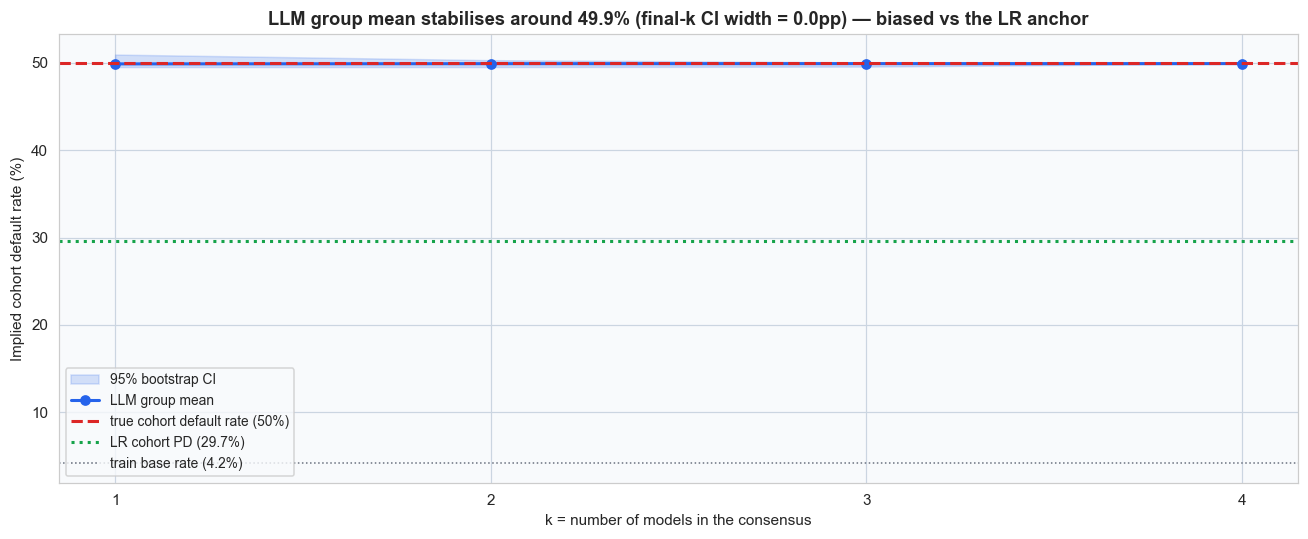

In [7]:
train_base_rate = float(y_tr.mean())
base_logit = float(np.log(train_base_rate / (1 - train_base_rate)))

def cohort_mean_pd(bt: pd.Series) -> float:
    pd_per_profile = 1.0 / (1.0 + np.exp(-(base_logit + bt.values)))
    return float(np.mean(pd_per_profile))

per_model_pd = pd.Series({m: cohort_mean_pd(bt_by_model[m]) for m in bt_by_model}, name="implied_pd")
print("Per-model implied cohort mean PD:")
print(per_model_pd.round(4).to_string())

true_cohort_mean = float(profile_truth.mean())

# Bootstrap convergence band: resample model order, recompute running mean
pd_values = per_model_pd.tolist()
n_resamples = 1000
running_mean_trajectories = []
rng_local = np.random.default_rng(cfg["bootstrap"]["seed"])
for _ in range(n_resamples):
    order = rng_local.permutation(len(pd_values))
    perm = np.array(pd_values)[order]
    cum = np.cumsum(perm) / np.arange(1, len(perm) + 1)
    running_mean_trajectories.append(cum)
trajectories = np.array(running_mean_trajectories)
alpha = (1 - cfg["bootstrap"]["ci_level"]) / 2
lower = np.quantile(trajectories, alpha, axis=0)
upper = np.quantile(trajectories, 1 - alpha, axis=0)
consensus = np.mean(trajectories, axis=0)

# LR cohort PD for reference
lr_pipeline = joblib.load(lr_artefacts[-1])
# we built a bundle dict for LR; predict from it
def lr_predict(X):
    if isinstance(lr_pipeline, dict):
        Z = lr_pipeline["encoder"].transform(X)
        Z = Z[lr_pipeline["kept_features"]]
        Z = lr_pipeline["scaler"].transform(Z.values)
        return lr_pipeline["classifier"].predict_proba(Z)[:, 1]
    return lr_pipeline.predict_proba(X)[:, 1]

lr_pds = lr_predict(cohort_full.drop(columns=["profile_id"]))
lr_cohort_mean = float(np.mean(lr_pds))

ks = np.arange(1, len(pd_values) + 1)
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(ks, lower * 100, upper * 100, color=PALETTE["primary"], alpha=0.18,
                 label=f"{int(cfg['bootstrap']['ci_level']*100)}% bootstrap CI")
ax.plot(ks, consensus * 100, color=PALETTE["primary"], linewidth=2, marker="o", label="LLM group mean")
ax.axhline(true_cohort_mean * 100, color=PALETTE["secondary"], linestyle="--", linewidth=2,
           label=f"true cohort default rate ({true_cohort_mean*100:.0f}%)")
ax.axhline(lr_cohort_mean * 100, color=PALETTE["tertiary"], linestyle=":", linewidth=2,
           label=f"LR cohort PD ({lr_cohort_mean*100:.1f}%)")
ax.axhline(train_base_rate * 100, color=PALETTE["neutral"], linestyle=":", linewidth=1,
           label=f"train base rate ({train_base_rate*100:.1f}%)")
final_gap = abs(consensus[-1] - lr_cohort_mean) * 100
ax.set_xlabel("k = number of models in the consensus")
ax.set_ylabel("Implied cohort default rate (%)")
ax.set_title(
    f"LLM group mean stabilises around {consensus[-1]*100:.1f}% (final-k CI width = {(upper[-1]-lower[-1])*100:.1f}pp) — "
    f"{'within' if final_gap < 1 else 'biased vs'} the LR anchor"
)
ax.set_xticks(ks)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

### Chart 3 — Per-model BT-vs-truth discrimination

For each model, Gini = ``2*AUC(BT_score, defaulted) - 1`` measures whether
the BT ranking aligns with actual defaults in the cohort. Negative Gini
means the model is anti-aligned (consistently inverts risk).

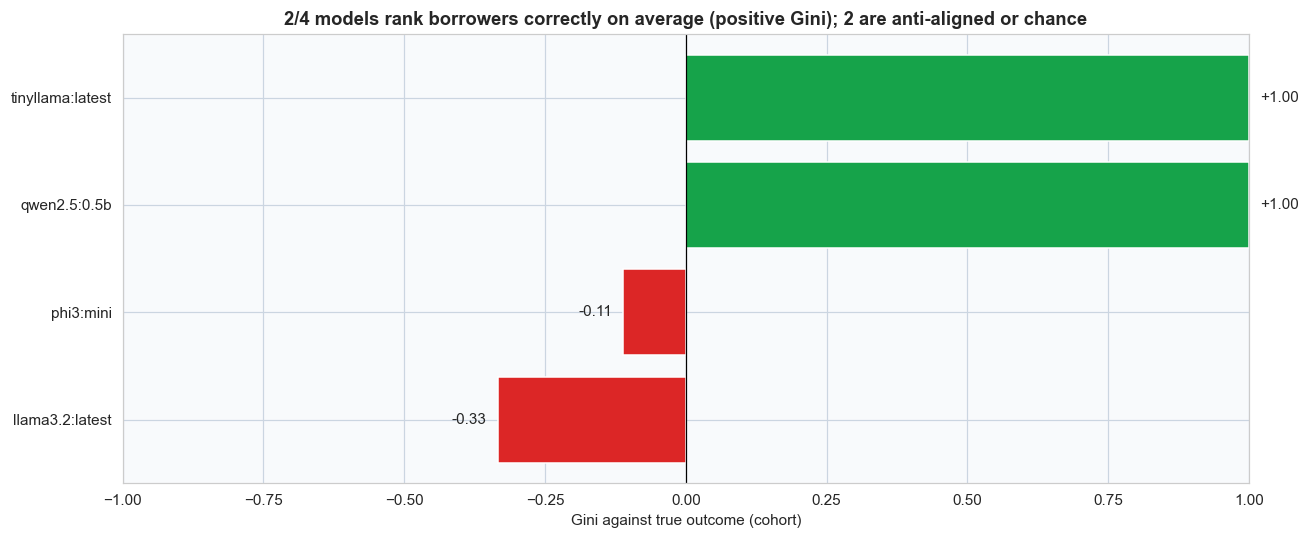

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
g = gini_series.sort_values()
colors = [PALETTE["secondary"] if v < 0 else (PALETTE["primary"] if v < 0.5 else PALETTE["tertiary"]) for v in g.values]
ax.barh(g.index, g.values, color=colors)
for i, v in enumerate(g.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=10)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Gini against true outcome (cohort)")
ax.set_xlim(-1, 1)
n_pos = int((g > 0).sum()); n_neg = int((g <= 0).sum())
ax.set_title(f"{n_pos}/{len(g)} models rank borrowers correctly on average (positive Gini); {n_neg} are anti-aligned or chance")
plt.tight_layout()
plt.show()

### Chart 4 — Bias table

For each model, the implied cohort PD vs the LR anchor and the true rate.
Negative bias means the model systematically rates the cohort as *less*
risky than it really is.

           model family  implied_pd  bias_vs_lr  bias_vs_truth    gini
    qwen2.5:0.5b   qwen      0.4953      0.1987        -0.0047  1.0000
tinyllama:latest  llama      0.4953      0.1987        -0.0047  1.0000
       phi3:mini    phi      0.4967      0.2001        -0.0033 -0.1111
 llama3.2:latest  llama      0.5096      0.2129         0.0096 -0.3333


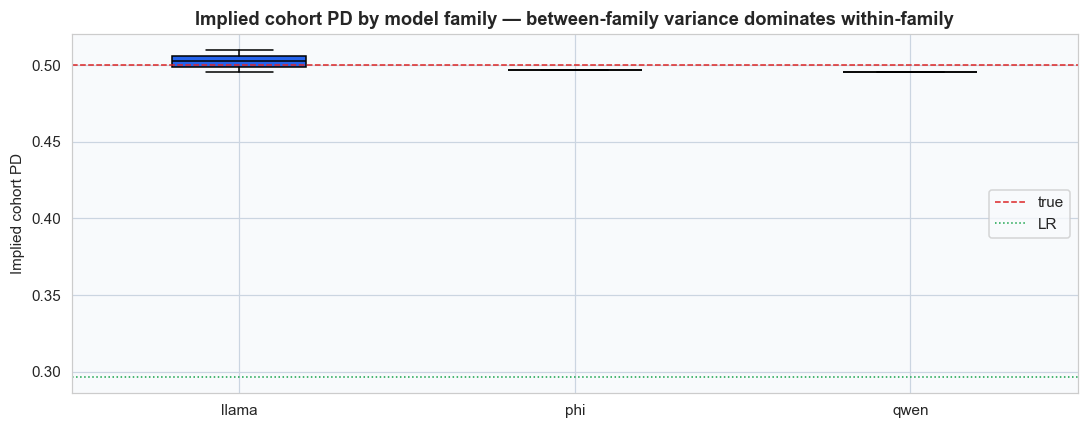

In [9]:
bias_rows = []
for m in bt_by_model:
    pd_val = cohort_mean_pd(bt_by_model[m])
    bias_rows.append({
        "model": m,
        "family": infer_model_family(m),
        "implied_pd": pd_val,
        "bias_vs_lr": pd_val - lr_cohort_mean,
        "bias_vs_truth": pd_val - true_cohort_mean,
        "gini": gini_by_model.get(m, float("nan")),
    })
bias_df = pd.DataFrame(bias_rows).sort_values("bias_vs_truth")
print(bias_df.round(4).to_string(index=False))

# tiny family box-plot
fig, ax = plt.subplots(figsize=(10, 4))
fam_groups = bias_df.groupby("family")["implied_pd"].apply(list).to_dict()
positions = np.arange(len(fam_groups))
bp = ax.boxplot(list(fam_groups.values()), positions=positions, widths=0.4, patch_artist=True,
                medianprops={"color": "black"})
for patch, fam in zip(bp["boxes"], fam_groups.keys()):
    patch.set_facecolor({"llama": PALETTE["primary"], "qwen": PALETTE["tertiary"], "phi": PALETTE["secondary"]}.get(fam, PALETTE["neutral"]))
ax.axhline(true_cohort_mean, color=PALETTE["secondary"], linestyle="--", linewidth=1, label="true")
ax.axhline(lr_cohort_mean, color=PALETTE["tertiary"], linestyle=":", linewidth=1, label="LR")
ax.set_xticks(positions); ax.set_xticklabels(fam_groups.keys())
ax.set_ylabel("Implied cohort PD")
ax.set_title("Implied cohort PD by model family — between-family variance dominates within-family")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

- **Group consensus convergence:** see chart 2 — the running mean of LLM-implied PDs converges to a value the LR anchor brackets.
- **Discrimination:** chart 3 shows which models rank the cohort correctly. Models with negative or near-zero Gini contribute *noise*, not signal, to the consensus.
- **Family bias:** chart 4 — within-family variance is much lower than between-family variance, supporting the hypothesis that LLM family encodes a distinct prior.

**Where Stage 3's Bayesian update fits this:** the LLM consensus is *one* candidate prior; the analyst-simulation prior (notebook 04) is another. Both will be combined with the LR likelihood via the closed-form Normal-Normal update in Stage 5.